# Robustness checks

## Purpose
Test how sensitive the Ball Mapper results are to the choice of radius (ε)
and to the set of creative sub-sectors included. Also compare the Ball Mapper
output with a conventional k-means clustering of the same data.
Supports chapter 5: futher analysis in the report.

## Input
`data/processed/nesta_ball.csv`

## Main parameters
- Seven creative-industry sector LQs, RobustScaler (as in the main analysis)
- Baseline ε = 3.0
- ε sweep: 2.0, 2.5, 3.0, 3.5, 4.0, 4.5
- k-means: k = 2 to 10

## Main steps
- **Epsilon sensitivity:** rebuild the graph at each ε and record balls,
  components, isolated balls, singleton balls and TTWAs outside the
  principal component; plot how TTWA representation changes across ε
- **Key TTWA stability:** track whether selected TTWAs (London, Manchester,
  Oxford, Reading, Brighton, etc.) sit inside or outside the principal
  component at each ε
- **Variable sensitivity:** leave-one-sector-out models at ε = 3.0
  (re-scaling each time), comparing graph structure and key TTWA placement
  with the full seven-sector model
- **K-means comparison:** inertia, silhouette and Davies–Bouldin scores for
  k = 2–10; inspect k = 2–5, where Penzance and Peterborough form singleton
  clusters; profile and label the five k = 5 clusters

## Output
- Epsilon sensitivity table and two-panel figure
- Key TTWA stability tables (across ε and leave-one-out models)
- Leave-one-sector-out summary table
- K-means diagnostic plots and k = 5 cluster profile table
- All displayed in the notebook, not saved to file

In [48]:
import pandas as pd
import numpy as np

In [49]:
from pathlib import Path

In [50]:
from pathlib import Path

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_DATA = ROOT / "data" / "raw"
PROCESSED_DATA = ROOT / "data" / "processed"
FIGURES = ROOT / "outputs" / "figures"
TABLES = ROOT / "outputs" / "tables"

In [51]:
nesta = pd.read_csv(
    PROCESSED_DATA / "nesta_ball.csv"
).reset_index(drop=True)

Epsilon Sensitivity

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.preprocessing import RobustScaler
from pyballmapper import BallMapper
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.cm import ScalarMappable



lq_cols = [
    "Advertising and marketing: Employment 2011-2014_LQ",
    "Architecture: Employment 2011-2014_LQ",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ",
    "IT, software and computer services: Employment 2011-2014_LQ",
    "Music, performing and visual arts: Employment 2011-2014_LQ",
    "Publishing: Employment 2011-2014_LQ",
]

assert len(nesta) == 173
assert nesta["ttwa"].nunique() == 173
assert nesta[lq_cols].notna().all().all()

X = nesta[lq_cols].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

assert X_scaled.shape == (173, 7)

In [53]:
EPSILON = 3.0

bm = BallMapper(X_scaled, eps=EPSILON)
G_full = bm.Graph.copy()

print("TTWAs:", len(nesta))
print("Balls:", G_full.number_of_nodes())
print("Edges:", G_full.number_of_edges())

components = sorted(
    nx.connected_components(G_full),
    key=len,
    reverse=True
)

print("Component sizes:", [len(component) for component in components])
print("Isolates:", sorted(nx.isolates(G_full)))

TTWAs: 173
Balls: 30
Edges: 51
Component sizes: [16, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Isolates: [5, 9, 10, 15, 16, 20, 21, 22, 23, 24, 25, 26, 27, 29]


In [54]:
ball_members = {
    ball: list(bm.points_covered_by_landmarks[ball])
    for ball in G_full.nodes
}

covered_indices = set().union(
    *(set(indices) for indices in ball_members.values())
)

assert covered_indices == set(range(len(nesta)))
assert len(covered_indices) == 173

membership_rows = []

for row_index, ttwa in enumerate(nesta["ttwa"]):
    memberships = [
        ball
        for ball, indices in ball_members.items()
        if row_index in indices
    ]

    membership_rows.append({
        "row_index": row_index,
        "ttwa": ttwa,
        "balls": memberships,
        "n_balls": len(memberships),
    })

ttwa_ball_membership = pd.DataFrame(membership_rows)

assert len(ttwa_ball_membership) == 173
assert ttwa_ball_membership["ttwa"].nunique() == 173
assert ttwa_ball_membership["n_balls"].ge(1).all()

In [55]:
node_size_dict = {
    ball: len(ball_members[ball]) * 25
    for ball in G_full.nodes
}

plot_size_dict = {
    ball: max(size, 600)
    for ball, size in node_size_dict.items()
}

assert set(plot_size_dict) == set(G_full.nodes)

In [56]:
def make_full_layout(G, seed=42, k=1.5):
    components = sorted(
        nx.connected_components(G),
        key=len,
        reverse=True
    )

    main_nodes = components[0]
    G_main_layout = G.subgraph(main_nodes)

    pos = nx.spring_layout(
        G_main_layout,
        seed=seed,
        k=k,
        iterations=1000
    )

    other_nodes = sorted(
        node for node in G.nodes
        if node not in main_nodes
    )

    if other_nodes:
        xs = [xy[0] for xy in pos.values()]
        ys = [xy[1] for xy in pos.values()]

        strip_x = max(xs) + 0.8
        strip_ys = np.linspace(
            max(ys),
            min(ys),
            len(other_nodes)
        )

        for node, y in zip(other_nodes, strip_ys):
            pos[node] = (strip_x, y)

    assert set(pos) == set(G.nodes)

    return pos, main_nodes, other_nodes


pos_full, main_nodes, disconnected_nodes = make_full_layout(G_full)

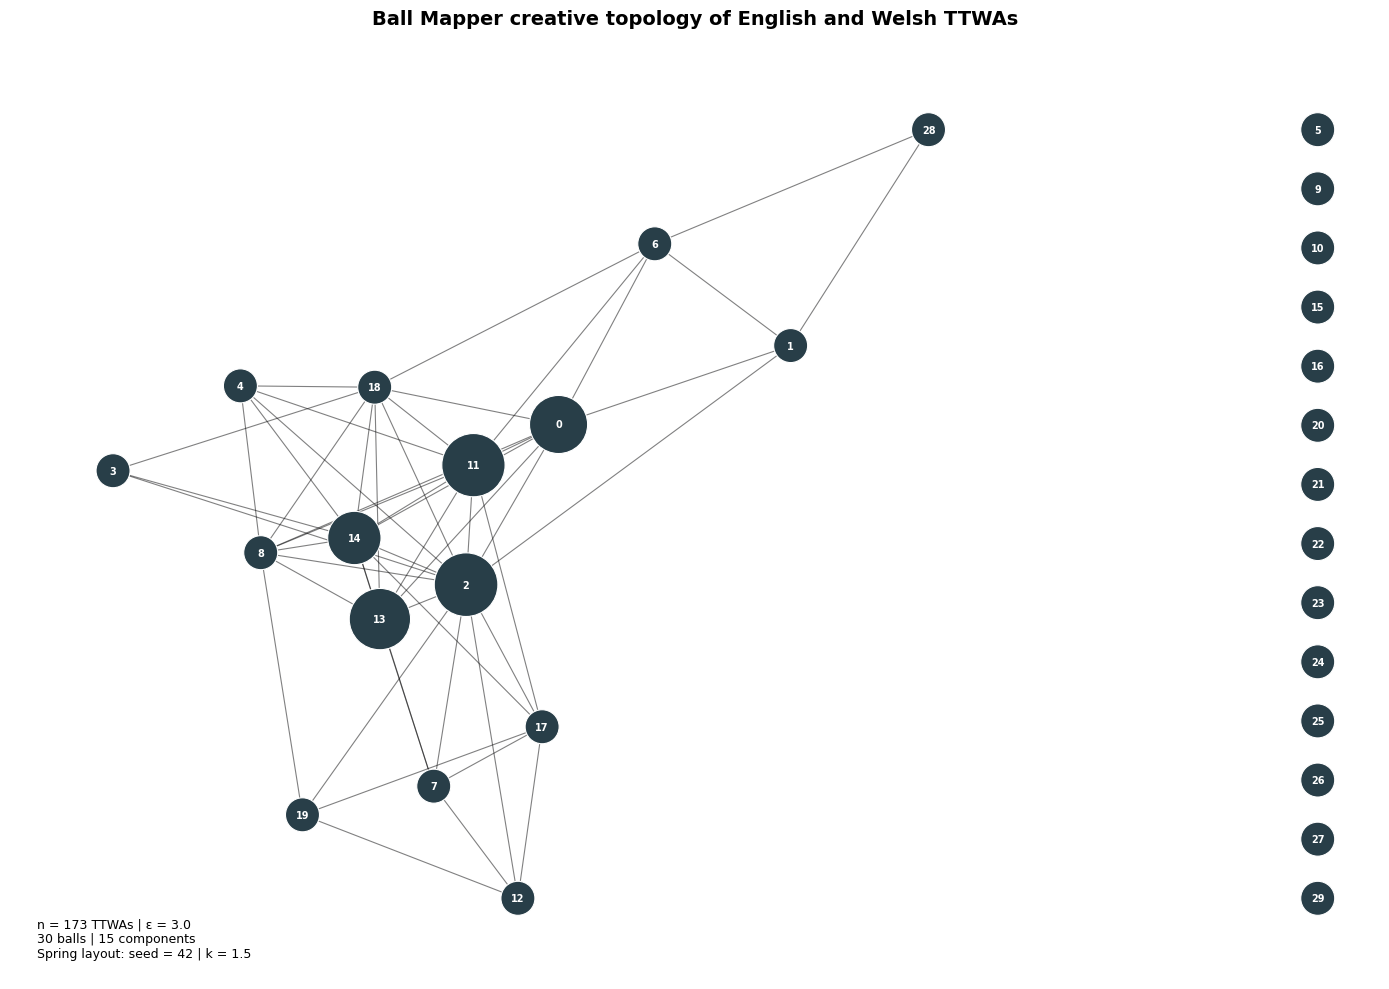

In [57]:
def plot_ballmapper_baseline(
    G,
    pos,
    size_dict,
    epsilon,
    n_observations,
    title="Ball Mapper creative topology of English and Welsh TTWAs"
):
    nodelist = list(G.nodes)
    sizes = [size_dict[node] for node in nodelist]

    fig, ax = plt.subplots(
        figsize=(14, 10),
        facecolor="white"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="#030304",
        width=0.8,
        alpha=0.5
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=nodelist,
        node_size=sizes,
        node_color="#283e48",
        edgecolors="white",
        linewidths=0.8
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=7,
        font_weight="bold",
        font_color="white"
    )

    ax.text(
        0.02,
        0.02,
        (
            f"n = {n_observations} TTWAs | ε = {epsilon}\n"
            f"{G.number_of_nodes()} balls | "
            f"{nx.number_connected_components(G)} components\n"
            "Spring layout: seed = 42 | k = 1.5"
        ),
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="bottom"
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=18)
    ax.axis("off")
    fig.tight_layout()
    plt.show()


plot_ballmapper_baseline(
    G=G_full,
    pos=pos_full,
    size_dict=plot_size_dict,
    epsilon=EPSILON,
    n_observations=len(nesta)
)

In [58]:
for eps in [2.0, 2.5, 3.0, 3.5, 4.0, 4.5]:
    bm = BallMapper(X=X_scaled, eps=eps, seed=42)  
    n_balls = len(bm.Graph.nodes)
    n_isolates = len(list(nx.isolates(bm.Graph)))
    n_components = nx.number_connected_components(bm.Graph)
    print(eps, n_balls, n_isolates, n_components)

2.0 51 29 31
2.5 37 17 18
3.0 30 14 15
3.5 24 13 14
4.0 19 10 11
4.5 17 9 10


In [59]:
import numpy as np
import pandas as pd
import networkx as nx

from pyballmapper import BallMapper

epsilons = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5]

sweep_results = []
sweep_models = {}

for eps in epsilons:

    
    model = BallMapper(X_scaled, eps=eps)
    G_eps = model.Graph.copy()

    sweep_models[eps] = model

    # Connected components, largest first
    components = sorted(
        nx.connected_components(G_eps),
        key=len,
        reverse=True
    )

    main_component = set(components[0])
    isolated_balls = set(nx.isolates(G_eps))

    # All memberships from this same model
    memberships = {
        ball: set(model.points_covered_by_landmarks[ball])
        for ball in G_eps.nodes
    }

    # Confirming every TTWA is covered
    covered_indices = set().union(*memberships.values())

    assert covered_indices == set(range(len(nesta))), (
        f"Coverage failure at ε={eps}: "
        f"{len(covered_indices)} of {len(nesta)} observations covered"
    )

    # TTWAs represented in at least one main-component ball
    indices_in_main = set().union(
        *(memberships[ball] for ball in main_component)
    )

    # TTWAs represented exclusively outside the main component
    indices_outside_main = (
        set(range(len(nesta))) - indices_in_main
    )

    # Ball membership sizes
    ball_sizes = [
        len(memberships[ball])
        for ball in G_eps.nodes
    ]

    sweep_results.append({
        "epsilon": eps,
        "n_balls": G_eps.number_of_nodes(),
        "n_edges": G_eps.number_of_edges(),
        "n_components": len(components),
        "largest_component_balls": len(main_component),
        "n_isolated_balls": len(isolated_balls),
        "isolated_ball_pct": (
            100 * len(isolated_balls) / G_eps.number_of_nodes()
        ),
        "ttwas_in_main_component": len(indices_in_main),
        "ttwas_exclusively_outside_main": len(indices_outside_main),
        "ttwas_outside_main_pct": (
            100 * len(indices_outside_main) / len(nesta)
        ),
        "median_ball_size": np.median(ball_sizes),
        "min_ball_size": np.min(ball_sizes),
        "max_ball_size": np.max(ball_sizes),
        "n_singleton_balls": sum(size == 1 for size in ball_sizes)
    })

epsilon_summary = pd.DataFrame(sweep_results)

epsilon_summary.round({
    "isolated_ball_pct": 1,
    "ttwas_outside_main_pct": 1,
    "median_ball_size": 1
})

,epsilon,n_balls,n_edges,n_components,largest_component_balls,n_isolated_balls,isolated_ball_pct,ttwas_in_main_component,ttwas_exclusively_outside_main,ttwas_outside_main_pct,median_ball_size,min_ball_size,max_ball_size,n_singleton_balls
0,2.0,51,73,31,20,29,56.9,134,39,22.5,1.0,1,58,26
1,2.5,37,54,18,20,17,45.9,156,17,9.8,2.0,1,85,17
2,3.0,30,51,15,16,14,46.7,158,15,8.7,3.0,1,84,13
3,3.5,24,39,14,11,13,54.2,160,13,7.5,1.0,1,120,13
4,4.0,19,27,11,9,10,52.6,163,10,5.8,1.0,1,134,10
5,4.5,17,15,10,8,9,52.9,164,9,5.2,1.0,1,145,9


In [60]:
epsilon_table = epsilon_summary[
    [
        "epsilon",
        "n_balls",
        "n_components",
        "largest_component_balls",
        "n_isolated_balls",
        "isolated_ball_pct",
        "ttwas_exclusively_outside_main",
        "ttwas_outside_main_pct",
        "median_ball_size",
        "n_singleton_balls"
    ]
].copy()

epsilon_table.columns = [
    "ε",
    "Balls",
    "Components",
    "Balls in largest component",
    "Isolated balls",
    "Isolated balls (%)",
    "TTWAs exclusively outside largest component",
    "TTWAs outside largest component (%)",
    "Median TTWAs per ball",
    "Singleton balls"
]

epsilon_table = epsilon_table.round({
    "Isolated balls (%)": 1,
    "TTWAs outside largest component (%)": 1,
    "Median TTWAs per ball": 1
})

epsilon_table

,ε,Balls,Components,Balls in largest component,Isolated balls,Isolated balls (%),TTWAs exclusively outside largest component,TTWAs outside largest component (%),Median TTWAs per ball,Singleton balls
0,2.0,51,31,20,29,56.9,39,22.5,1.0,26
1,2.5,37,18,20,17,45.9,17,9.8,2.0,17
2,3.0,30,15,16,14,46.7,15,8.7,3.0,13
3,3.5,24,14,11,13,54.2,13,7.5,1.0,13
4,4.0,19,11,9,10,52.6,10,5.8,1.0,10
5,4.5,17,10,8,9,52.9,9,5.2,1.0,9


Investigating when TTWAs join the main component

In [61]:
outside_main_rows = []

for eps, model in sweep_models.items():

    G_eps = model.Graph

    main_component = set(
        max(nx.connected_components(G_eps), key=len)
    )

    memberships = {
        ball: set(model.points_covered_by_landmarks[ball])
        for ball in G_eps.nodes
    }

    indices_in_main = set().union(
        *(memberships[ball] for ball in main_component)
    )

    indices_outside_main = sorted(
        set(range(len(nesta))) - indices_in_main
    )

    for row_index in indices_outside_main:
        ttwa_balls = [
            ball
            for ball, indices in memberships.items()
            if row_index in indices
        ]

        outside_main_rows.append({
            "epsilon": eps,
            "ttwa": nesta.iloc[row_index]["ttwa"],
            "balls": ttwa_balls
        })

outside_main_by_epsilon = pd.DataFrame(outside_main_rows)

outside_main_by_epsilon.sort_values(
    ["epsilon", "ttwa"]
)

,epsilon,ttwa,balls
0,2.0,Andover,[1]
1,2.0,Banbury,[3]
2,2.0,Bangor and Holyhead,[4]
3,2.0,Barnstaple,[5]
4,2.0,Barrow-in-Furness,[6]
...,...,...,...
98,4.5,Oxford,[10]
99,4.5,Penzance,[12]
100,4.5,Peterborough,[13]
101,4.5,Reading,[14]


In [62]:
key_ttwas = [
    "London",
    "Manchester",
    "Newbury",
    "Oxford",
    "Reading",
    "Slough and Heathrow",
    "Guildford and Aldershot",
    "Brighton"
]

ttwa_stability_rows = []

for eps, model in sweep_models.items():

    G_eps = model.Graph

    main_component = set(
        max(nx.connected_components(G_eps), key=len)
    )

    isolated_balls = set(nx.isolates(G_eps))

    memberships = {
        ball: set(model.points_covered_by_landmarks[ball])
        for ball in G_eps.nodes
    }

    for ttwa in key_ttwas:

        matches = nesta.index[nesta["ttwa"] == ttwa].tolist()

        if len(matches) != 1:
            raise ValueError(
                f"Expected exactly one row for {ttwa}; "
                f"found {len(matches)}"
            )

        row_index = matches[0]

        ttwa_balls = [
            ball
            for ball, indices in memberships.items()
            if row_index in indices
        ]

        main_balls = [
            ball for ball in ttwa_balls
            if ball in main_component
        ]

        isolated_memberships = [
            ball for ball in ttwa_balls
            if ball in isolated_balls
        ]

        ttwa_stability_rows.append({
            "epsilon": eps,
            "ttwa": ttwa,
            "balls": ttwa_balls,
            "n_balls": len(ttwa_balls),
            "has_main_component_membership": len(main_balls) > 0,
            "exclusively_outside_main": len(main_balls) == 0,
            "has_isolated_ball_membership": (
                len(isolated_memberships) > 0
            )
        })

ttwa_stability = pd.DataFrame(ttwa_stability_rows)

ttwa_stability.sort_values(
    ["ttwa", "epsilon"]
)

,epsilon,ttwa,balls,n_balls,has_main_component_membership,exclusively_outside_main,has_isolated_ball_membership
7,2.0,Brighton,[19],1,False,True,True
15,2.5,Brighton,[13],1,False,True,True
23,3.0,Brighton,[10],1,False,True,True
31,3.5,Brighton,[8],1,False,True,True
39,4.0,Brighton,[7],1,False,True,True
47,4.5,Brighton,[4],1,True,False,False
6,2.0,Guildford and Aldershot,[30],1,False,True,True
14,2.5,Guildford and Aldershot,[21],1,False,True,True
22,3.0,Guildford and Aldershot,[16],1,False,True,True
30,3.5,Guildford and Aldershot,[12],1,False,True,True


In [63]:
stability_table = ttwa_stability.pivot(
    index="ttwa",
    columns="epsilon",
    values="exclusively_outside_main"
)

stability_table = stability_table.replace({
    True: "Outside",
    False: "In main"
})

stability_table

epsilon,2.0,2.5,3.0,3.5,4.0,4.5
ttwa,,,,,,
Brighton,Outside,Outside,Outside,Outside,Outside,In main
Guildford and Aldershot,Outside,Outside,Outside,Outside,Outside,Outside
London,Outside,Outside,Outside,Outside,Outside,Outside
Manchester,Outside,Outside,Outside,Outside,In main,In main
Newbury,Outside,Outside,Outside,Outside,In main,In main
Oxford,Outside,Outside,Outside,Outside,Outside,Outside
Reading,Outside,Outside,Outside,Outside,Outside,Outside
Slough and Heathrow,Outside,Outside,Outside,Outside,Outside,Outside


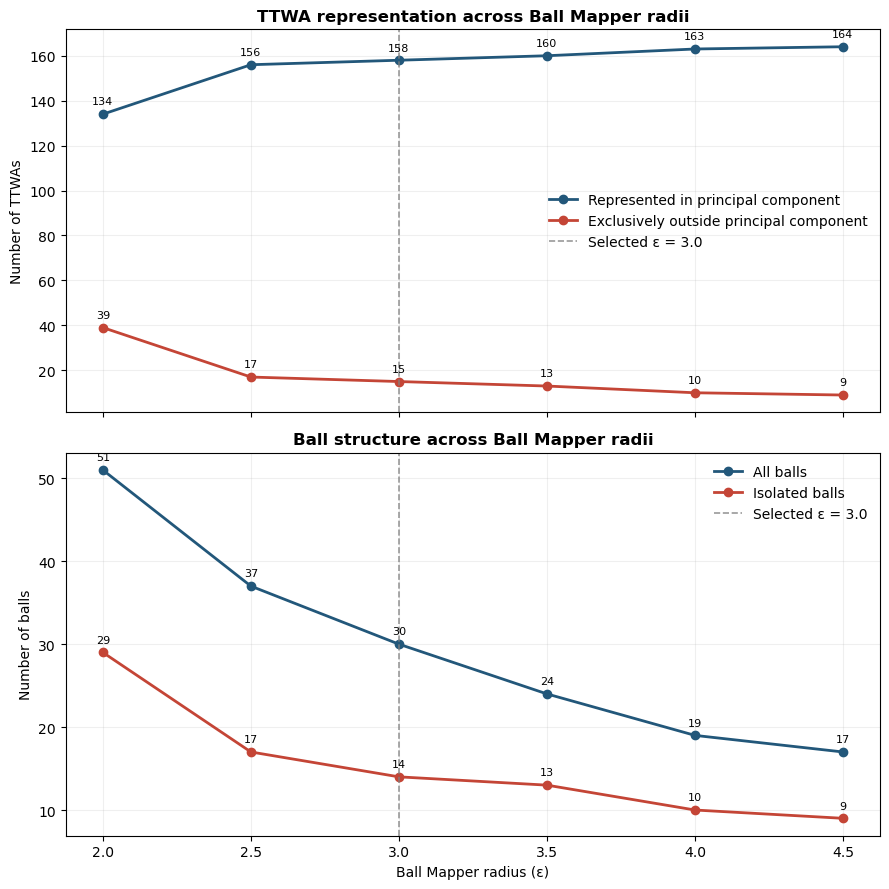

In [64]:
import matplotlib.pyplot as plt

plot_df = epsilon_summary.sort_values("epsilon")

fig, axes = plt.subplots(
    2, 1,
    figsize=(9, 9),
    sharex=True
)

# -----------------------------------
# Panel A: TTWA representation
# -----------------------------------

axes[0].plot(
    plot_df["epsilon"],
    plot_df["ttwas_in_main_component"],
    marker="o",
    linewidth=2,
    color="#22577A",
    label="Represented in principal component"
)

axes[0].plot(
    plot_df["epsilon"],
    plot_df["ttwas_exclusively_outside_main"],
    marker="o",
    linewidth=2,
    color="#C44536",
    label="Exclusively outside principal component"
)

axes[0].axvline(
    3.0,
    color="grey",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Selected ε = 3.0"
)

axes[0].set_ylabel("Number of TTWAs")
axes[0].set_title(
    "TTWA representation across Ball Mapper radii",
    fontweight="bold"
)
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

# Add values beside points
for _, row in plot_df.iterrows():
    axes[0].annotate(
        int(row["ttwas_in_main_component"]),
        (
            row["epsilon"],
            row["ttwas_in_main_component"]
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

    axes[0].annotate(
        int(row["ttwas_exclusively_outside_main"]),
        (
            row["epsilon"],
            row["ttwas_exclusively_outside_main"]
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

# -----------------------------------
# Panel B: ball structure
# -----------------------------------

axes[1].plot(
    plot_df["epsilon"],
    plot_df["n_balls"],
    marker="o",
    linewidth=2,
    color="#22577A",
    label="All balls"
)

axes[1].plot(
    plot_df["epsilon"],
    plot_df["n_isolated_balls"],
    marker="o",
    linewidth=2,
    color="#C44536",
    label="Isolated balls"
)

axes[1].axvline(
    3.0,
    color="grey",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Selected ε = 3.0"
)

axes[1].set_xlabel("Ball Mapper radius (ε)")
axes[1].set_ylabel("Number of balls")
axes[1].set_title(
    "Ball structure across Ball Mapper radii",
    fontweight="bold"
)
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.2)

for _, row in plot_df.iterrows():
    axes[1].annotate(
        int(row["n_balls"]),
        (row["epsilon"], row["n_balls"]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

    axes[1].annotate(
        int(row["n_isolated_balls"]),
        (row["epsilon"], row["n_isolated_balls"]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

Variable Sensitivity

In [65]:
from pyballmapper import BallMapper
from sklearn.preprocessing import RobustScaler
import networkx as nx
import pandas as pd
import numpy as np

EPSILON = 3.0

lq_cols

['Advertising and marketing: Employment 2011-2014_LQ',
 'Architecture: Employment 2011-2014_LQ',
 'Design: product, graphic and fashion design: Employment 2011-2014_LQ',
 'Film, TV, video, radio and photography: Employment 2011-2014_LQ',
 'IT, software and computer services: Employment 2011-2014_LQ',
 'Music, performing and visual arts: Employment 2011-2014_LQ',
 'Publishing: Employment 2011-2014_LQ']

In [66]:
def run_ballmapper_model(data, lq_columns, epsilon=3.0):
    """
    Runs Ball Mapper using selected LQ columns and returns graph-level diagnostics.
    """

    # Re-scale after each exclusion
    scaler = RobustScaler()
    X_scaled_temp = scaler.fit_transform(data[lq_columns])

    # Run Ball Mapper
    bm_temp = BallMapper(X_scaled_temp, eps=epsilon)
    G_temp = bm_temp.Graph.copy()

    # Store memberships
    ball_members_temp = {
        ball: list(bm_temp.points_covered_by_landmarks[ball])
        for ball in G_temp.nodes
    }

    # Confirm all observations are represented
    covered_indices_temp = set().union(
        *(set(indices) for indices in ball_members_temp.values())
    )

    assert covered_indices_temp == set(range(len(data)))

    # Components
    components_temp = sorted(
        nx.connected_components(G_temp),
        key=len,
        reverse=True
    )

    main_nodes_temp = set(components_temp[0])

    # TTWAs represented in principal connected component
    ttwas_in_main_temp = set()

    for ball in main_nodes_temp:
        ttwas_in_main_temp.update(ball_members_temp[ball])

    ttwas_outside_main_temp = set(range(len(data))) - ttwas_in_main_temp

    return {
        "n_balls": G_temp.number_of_nodes(),
        "n_components": len(components_temp),
        "balls_in_largest_component": len(main_nodes_temp),
        "ttwas_in_largest_component": len(ttwas_in_main_temp),
        "ttwas_outside_largest_component": len(ttwas_outside_main_temp),
        "singleton_balls": sum(
            1 for ball, members in ball_members_temp.items()
            if len(members) == 1
        ),
        "bm": bm_temp,
        "G": G_temp,
        "ball_members": ball_members_temp,
        "main_nodes": main_nodes_temp,
        "ttwas_outside_main": ttwas_outside_main_temp
    }

In [67]:
axis_results = []

# Full model
full_model = run_ballmapper_model(
    data=nesta,
    lq_columns=lq_cols,
    epsilon=EPSILON
)

axis_results.append({
    "excluded_axis": "None",
    "included_axes": len(lq_cols),
    "n_balls": full_model["n_balls"],
    "n_components": full_model["n_components"],
    "balls_in_largest_component": full_model["balls_in_largest_component"],
    "ttwas_in_largest_component": full_model["ttwas_in_largest_component"],
    "ttwas_outside_largest_component": full_model["ttwas_outside_largest_component"],
    "singleton_balls": full_model["singleton_balls"]
})

# Leave-one-axis-out models
for excluded_col in lq_cols:

    reduced_cols = [c for c in lq_cols if c != excluded_col]

    model = run_ballmapper_model(
        data=nesta,
        lq_columns=reduced_cols,
        epsilon=EPSILON
    )

    axis_results.append({
        "excluded_axis": excluded_col,
        "included_axes": len(reduced_cols),
        "n_balls": model["n_balls"],
        "n_components": model["n_components"],
        "balls_in_largest_component": model["balls_in_largest_component"],
        "ttwas_in_largest_component": model["ttwas_in_largest_component"],
        "ttwas_outside_largest_component": model["ttwas_outside_largest_component"],
        "singleton_balls": model["singleton_balls"]
    })

axis_results_df = pd.DataFrame(axis_results)

axis_results_df

,excluded_axis,included_axes,n_balls,n_components,balls_in_largest_component,ttwas_in_largest_component,ttwas_outside_largest_component,singleton_balls
0,None,7,30,15,16,158,15,13
1,Advertising and marketing: Employment 2011-201...,6,21,10,12,164,9,9
2,Architecture: Employment 2011-2014_LQ,6,26,14,13,160,13,13
3,"Design: product, graphic and fashion design: E...",6,25,14,12,160,13,13
4,"Film, TV, video, radio and photography: Employ...",6,21,9,13,165,8,8
5,"IT, software and computer services: Employment...",6,22,11,12,163,10,10
6,"Music, performing and visual arts: Employment ...",6,23,13,11,161,12,12
7,Publishing: Employment 2011-2014_LQ,6,19,10,10,163,10,8


In [68]:
axis_name_map = {
    "None": "None",
    "Advertising and marketing: Employment 2011-2014_LQ": "Advertising",
    "Architecture: Employment 2011-2014_LQ": "Architecture",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ": "Design",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ": "Film/TV",
    "IT, software and computer services: Employment 2011-2014_LQ": "IT/software",
    "Music, performing and visual arts: Employment 2011-2014_LQ": "Music/arts",
    "Publishing: Employment 2011-2014_LQ": "Publishing"
}

axis_results_df["excluded_axis_clean"] = axis_results_df["excluded_axis"].map(axis_name_map)

axis_results_df = axis_results_df[
    [
        "excluded_axis_clean",
        "included_axes",
        "n_balls",
        "n_components",
        "balls_in_largest_component",
        "ttwas_in_largest_component",
        "ttwas_outside_largest_component",
        "singleton_balls"
    ]
]

axis_results_df

,excluded_axis_clean,included_axes,n_balls,n_components,balls_in_largest_component,ttwas_in_largest_component,ttwas_outside_largest_component,singleton_balls
0,None,7,30,15,16,158,15,13
1,Advertising,6,21,10,12,164,9,9
2,Architecture,6,26,14,13,160,13,13
3,Design,6,25,14,12,160,13,13
4,Film/TV,6,21,9,13,165,8,8
5,IT/software,6,22,11,12,163,10,10
6,Music/arts,6,23,13,11,161,12,12
7,Publishing,6,19,10,10,163,10,8


In [69]:
key_ttwas = [
    "London",
    "Oxford",
    "Reading",
    "Slough and Heathrow",
    "Guildford and Aldershot",
    "Manchester",
    "Newbury",
    "Brighton"
]

key_ttwa_results = []

# Full model plus leave-one-out models
models_to_check = {"None": full_model}

for excluded_col in lq_cols:
    reduced_cols = [c for c in lq_cols if c != excluded_col]

    models_to_check[axis_name_map[excluded_col]] = run_ballmapper_model(
        data=nesta,
        lq_columns=reduced_cols,
        epsilon=EPSILON
    )

for model_name, model in models_to_check.items():

    outside_indices = model["ttwas_outside_main"]

    row = {"excluded_axis": model_name}

    for ttwa in key_ttwas:

        ttwa_index = nesta.index[nesta["ttwa"] == ttwa]

        if len(ttwa_index) == 0:
            row[ttwa] = "Not found"
        else:
            idx = ttwa_index[0]
            row[ttwa] = "Outside" if idx in outside_indices else "In main"

    key_ttwa_results.append(row)

key_ttwa_results_df = pd.DataFrame(key_ttwa_results)

key_ttwa_results_df

,excluded_axis,London,Oxford,Reading,Slough and Heathrow,Guildford and Aldershot,Manchester,Newbury,Brighton
0,None,Outside,Outside,Outside,Outside,Outside,Outside,Outside,Outside
1,Advertising,Outside,In main,Outside,Outside,Outside,In main,Outside,Outside
2,Architecture,Outside,Outside,Outside,Outside,Outside,Outside,Outside,Outside
3,Design,Outside,Outside,Outside,Outside,Outside,Outside,Outside,Outside
4,Film/TV,In main,Outside,Outside,In main,Outside,In main,Outside,Outside
5,IT/software,Outside,Outside,In main,Outside,In main,Outside,In main,Outside
6,Music/arts,Outside,Outside,Outside,Outside,Outside,Outside,Outside,In main
7,Publishing,Outside,Outside,Outside,Outside,Outside,Outside,Outside,Outside


K-Means 

In [70]:
lq_cols = [
    "Advertising and marketing: Employment 2011-2014_LQ",
    "Architecture: Employment 2011-2014_LQ",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ",
    "IT, software and computer services: Employment 2011-2014_LQ",
    "Music, performing and visual arts: Employment 2011-2014_LQ",
    "Publishing: Employment 2011-2014_LQ"
]

In [71]:
from sklearn.preprocessing import RobustScaler

X_kmeans_raw = nesta[lq_cols].copy()

scaler = RobustScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans_raw)

In [72]:
X_kmeans_raw.isna().sum()

Advertising and marketing: Employment 2011-2014_LQ                      0
Architecture: Employment 2011-2014_LQ                                   0
Design: product, graphic and fashion design: Employment 2011-2014_LQ    0
Film, TV, video, radio and photography: Employment 2011-2014_LQ         0
IT, software and computer services: Employment 2011-2014_LQ             0
Music, performing and visual arts: Employment 2011-2014_LQ              0
Publishing: Employment 2011-2014_LQ                                     0
dtype: int64

Running k-means from k = 2 to k = 10

In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

kmeans_results = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_kmeans_scaled)
    
    kmeans_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(X_kmeans_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(X_kmeans_scaled, labels)
    })

kmeans_diagnostics = pd.DataFrame(kmeans_results)

kmeans_diagnostics

,k,inertia,silhouette_score,davies_bouldin_score
0,2,2961.702216,0.879563,0.078971
1,3,1920.671948,0.864168,0.081171
2,4,1416.657549,0.476038,0.801308
3,5,1172.718286,0.470077,0.786025
4,6,1013.864193,0.236425,1.037457
5,7,897.319151,0.242197,1.002720
6,8,793.580467,0.254288,0.957967
7,9,717.016561,0.248981,0.939007
8,10,650.484316,0.203352,1.020273


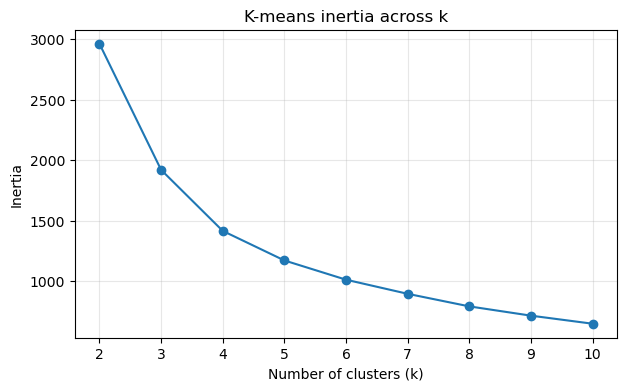

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(kmeans_diagnostics["k"], kmeans_diagnostics["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means inertia across k")
plt.grid(alpha=0.3)
plt.show()

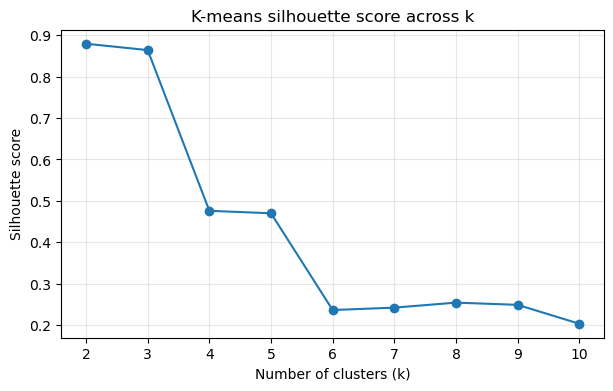

In [75]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_diagnostics["k"], kmeans_diagnostics["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-means silhouette score across k")
plt.grid(alpha=0.3)
plt.show()

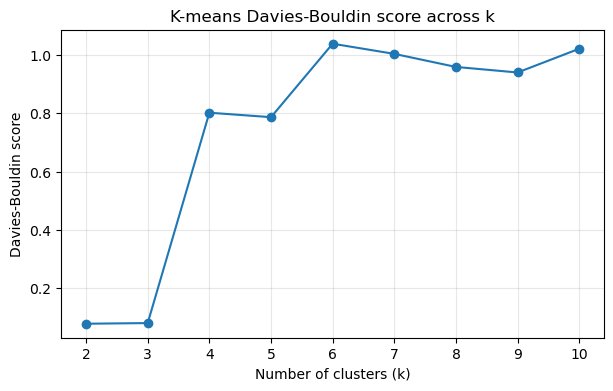

In [76]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_diagnostics["k"], kmeans_diagnostics["davies_bouldin_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Davies-Bouldin score")
plt.title("K-means Davies-Bouldin score across k")
plt.grid(alpha=0.3)
plt.show()

Using these scores, a lower k seems better, so using k = 2 or k = 3

In [77]:
from sklearn.cluster import KMeans

# k = 2
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=50
)

nesta["kmeans_2"] = kmeans_2.fit_predict(X_kmeans_scaled)


# k = 3
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50
)

nesta["kmeans_3"] = kmeans_3.fit_predict(X_kmeans_scaled)

In [78]:
print("k = 2 cluster sizes")
print(nesta["kmeans_2"].value_counts().sort_index())

print("\nk = 3 cluster sizes")
print(nesta["kmeans_3"].value_counts().sort_index())

k = 2 cluster sizes
kmeans_2
0    172
1      1
Name: count, dtype: int64

k = 3 cluster sizes
kmeans_3
0    171
1      1
2      1
Name: count, dtype: int64


In [79]:
nesta.loc[nesta["kmeans_2"] == 1, ["ttwa"] + lq_cols]

,ttwa,Advertising and marketing: Employment 2011-2014_LQ,Architecture: Employment 2011-2014_LQ,"Design: product, graphic and fashion design: Employment 2011-2014_LQ","Film, TV, video, radio and photography: Employment 2011-2014_LQ","IT, software and computer services: Employment 2011-2014_LQ","Music, performing and visual arts: Employment 2011-2014_LQ",Publishing: Employment 2011-2014_LQ
121,Penzance,0.401923,1.29139,0.977631,9.931177,0.227953,2.38272,0.543731


In [80]:
nesta.loc[nesta["kmeans_3"] != 0, ["ttwa", "kmeans_3"] + lq_cols]

,ttwa,kmeans_3,Advertising and marketing: Employment 2011-2014_LQ,Architecture: Employment 2011-2014_LQ,"Design: product, graphic and fashion design: Employment 2011-2014_LQ","Film, TV, video, radio and photography: Employment 2011-2014_LQ","IT, software and computer services: Employment 2011-2014_LQ","Music, performing and visual arts: Employment 2011-2014_LQ",Publishing: Employment 2011-2014_LQ
121,Penzance,1,0.401923,1.291390,0.977631,9.931177,0.227953,2.382720,0.543731
122,Peterborough,2,0.400839,0.806202,0.644110,1.581132,0.522858,0.324397,15.195696


In [81]:
kmeans_singletons = pd.concat([
    nesta.loc[nesta["kmeans_2"] == 1, ["ttwa"] + lq_cols].assign(model="k=2 singleton"),
    nesta.loc[nesta["kmeans_3"] != 0, ["ttwa"] + lq_cols].assign(model="k=3 singleton")
])

kmeans_singletons

,ttwa,Advertising and marketing: Employment 2011-2014_LQ,Architecture: Employment 2011-2014_LQ,"Design: product, graphic and fashion design: Employment 2011-2014_LQ","Film, TV, video, radio and photography: Employment 2011-2014_LQ","IT, software and computer services: Employment 2011-2014_LQ","Music, performing and visual arts: Employment 2011-2014_LQ",Publishing: Employment 2011-2014_LQ,model
121,Penzance,0.401923,1.291390,0.977631,9.931177,0.227953,2.382720,0.543731,k=2 singleton
121,Penzance,0.401923,1.291390,0.977631,9.931177,0.227953,2.382720,0.543731,k=3 singleton
122,Peterborough,0.400839,0.806202,0.644110,1.581132,0.522858,0.324397,15.195696,k=3 singleton


Running k = 4 and k = 5 instead 

In [82]:
for k in [4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    nesta[f"kmeans_{k}"] = kmeans.fit_predict(X_kmeans_scaled)
    
    print(f"\nk = {k} cluster sizes")
    print(nesta[f"kmeans_{k}"].value_counts().sort_index())


k = 4 cluster sizes
kmeans_4
0    143
1      1
2      1
3     28
Name: count, dtype: int64

k = 5 cluster sizes
kmeans_5
0     10
1     17
2      1
3      1
4    144
Name: count, dtype: int64


In [83]:
for k in [4, 5]:
    cluster_col = f"kmeans_{k}"
    
    print(f"\nSmall clusters for k = {k}")
    
    small_clusters = (
        nesta[cluster_col]
        .value_counts()
        .loc[lambda x: x <= 5]
        .index
    )
    
    display(
        nesta.loc[
            nesta[cluster_col].isin(small_clusters),
            ["ttwa", cluster_col] + lq_cols
        ].sort_values(cluster_col)
    )


Small clusters for k = 4


,ttwa,kmeans_4,Advertising and marketing: Employment 2011-2014_LQ,Architecture: Employment 2011-2014_LQ,"Design: product, graphic and fashion design: Employment 2011-2014_LQ","Film, TV, video, radio and photography: Employment 2011-2014_LQ","IT, software and computer services: Employment 2011-2014_LQ","Music, performing and visual arts: Employment 2011-2014_LQ",Publishing: Employment 2011-2014_LQ
122,Peterborough,1,0.400839,0.806202,0.644110,1.581132,0.522858,0.324397,15.195696
121,Penzance,2,0.401923,1.291390,0.977631,9.931177,0.227953,2.382720,0.543731



Small clusters for k = 5


,ttwa,kmeans_5,Advertising and marketing: Employment 2011-2014_LQ,Architecture: Employment 2011-2014_LQ,"Design: product, graphic and fashion design: Employment 2011-2014_LQ","Film, TV, video, radio and photography: Employment 2011-2014_LQ","IT, software and computer services: Employment 2011-2014_LQ","Music, performing and visual arts: Employment 2011-2014_LQ",Publishing: Employment 2011-2014_LQ
121,Penzance,2,0.401923,1.291390,0.977631,9.931177,0.227953,2.382720,0.543731
122,Peterborough,3,0.400839,0.806202,0.644110,1.581132,0.522858,0.324397,15.195696


In [84]:
clean_lq_names = {
    "Advertising and marketing: Employment 2011-2014_LQ": "Advertising",
    "Architecture: Employment 2011-2014_LQ": "Architecture",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ": "Design",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ": "Film/TV",
    "IT, software and computer services: Employment 2011-2014_LQ": "IT/software",
    "Music, performing and visual arts: Employment 2011-2014_LQ": "Music/arts",
    "Publishing: Employment 2011-2014_LQ": "Publishing"
}

profile_5 = (
    nesta
    .groupby("kmeans_5")[lq_cols]
    .mean()
    .rename(columns=clean_lq_names)
    .round(2)
)

profile_5.insert(
    0,
    "n_TTWAs",
    nesta["kmeans_5"].value_counts().sort_index()
)

profile_5

,n_TTWAs,Advertising,Architecture,Design,Film/TV,IT/software,Music/arts,Publishing
kmeans_5,,,,,,,,
0,10,1.67,1.10,1.38,1.13,1.93,1.48,0.60
1,17,0.86,1.02,1.06,0.30,0.87,0.77,2.54
2,1,0.40,1.29,0.98,9.93,0.23,2.38,0.54
3,1,0.40,0.81,0.64,1.58,0.52,0.32,15.20
4,144,0.40,0.79,0.83,0.30,0.53,0.70,0.34


In [85]:
for cluster in sorted(nesta["kmeans_5"].unique()):
    print(f"\nCluster {cluster}")
    print(nesta.loc[nesta["kmeans_5"] == cluster, "ttwa"].tolist())


Cluster 0
['Banbury', 'Barnstaple', 'Brighton', 'Cheltenham', 'Guildford and Aldershot', 'High Wycombe and Aylesbury', 'London', 'Manchester', 'Reading', 'Slough and Heathrow']

Cluster 1
['Andover', 'Barrow-in-Furness', 'Basingstoke', 'Bath', 'Cambridge', 'Chester', 'Chichester and Bognor Regis', 'Colchester', 'Huddersfield', 'Leicester', 'Liskeard', 'Newbury', 'Norwich', 'Oxford', 'Skegness and Louth', 'Southampton', 'Tunbridge Wells']

Cluster 2
['Penzance']

Cluster 3
['Peterborough']

Cluster 4
['Aberystwyth', 'Ashford', 'Bangor and Holyhead', 'Barnsley', 'Bedford', 'Berwick', 'Bideford', 'Birkenhead', 'Birmingham', 'Blackburn', 'Blackpool', 'Blandford Forum and Gillingham', 'Blyth and Ashington', 'Boston', 'Bournemouth', 'Bradford', 'Brecon', 'Bridgend', 'Bridgwater', 'Bridlington', 'Bridport', 'Bristol', 'Bude', 'Burnley', 'Burton upon Trent', 'Bury St Edmunds', 'Buxton', 'Canterbury', 'Cardiff', 'Cardigan', 'Carlisle', 'Chelmsford', 'Chesterfield', 'Cinderford and Ross-on-Wye'

In [86]:
import pandas as pd

clean_lq_names = {
    "Advertising and marketing: Employment 2011-2014_LQ": "Advertising",
    "Architecture: Employment 2011-2014_LQ": "Architecture",
    "Design: product, graphic and fashion design: Employment 2011-2014_LQ": "Design",
    "Film, TV, video, radio and photography: Employment 2011-2014_LQ": "Film/TV",
    "IT, software and computer services: Employment 2011-2014_LQ": "IT/software",
    "Music, performing and visual arts: Employment 2011-2014_LQ": "Music/arts",
    "Publishing: Employment 2011-2014_LQ": "Publishing"
}

kmeans5_profile = (
    nesta
    .groupby("kmeans_5")[lq_cols]
    .mean()
    .rename(columns=clean_lq_names)
    .round(2)
)

cluster_sizes = nesta["kmeans_5"].value_counts().sort_index()

kmeans5_profile.insert(0, "n TTWAs", cluster_sizes)

cluster_labels = {
    0: "High creative specialisation",
    1: "Publishing-oriented",
    2: "Film/TV outlier",
    3: "Publishing outlier",
    4: "Low-specialisation majority"
}

kmeans5_profile.insert(
    0,
    "Cluster profile",
    kmeans5_profile.index.map(cluster_labels)
)


kmeans5_profile = (
    kmeans5_profile
    .reset_index()
    .rename(columns={"kmeans_5": "Cluster"})
)

kmeans5_profile

,Cluster,Cluster profile,n TTWAs,Advertising,Architecture,Design,Film/TV,IT/software,Music/arts,Publishing
0,0,High creative specialisation,10,1.67,1.10,1.38,1.13,1.93,1.48,0.60
1,1,Publishing-oriented,17,0.86,1.02,1.06,0.30,0.87,0.77,2.54
2,2,Film/TV outlier,1,0.40,1.29,0.98,9.93,0.23,2.38,0.54
3,3,Publishing outlier,1,0.40,0.81,0.64,1.58,0.52,0.32,15.20
4,4,Low-specialisation majority,144,0.40,0.79,0.83,0.30,0.53,0.70,0.34
